In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Load data
df = pd.read_csv("vgsales.csv")

# See shape
print(f"Total games : {len(df)}")
print(f"Total columns: {len(df.columns)}")
print(f"\nColumn names:")
print(df.columns.tolist())

Total games : 16598
Total columns: 11

Column names:
['Rank', 'Name', 'Platform', 'Year', 'Genre', 'Publisher', 'NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales', 'Global_Sales']


In [2]:
#See first 5 rows:
df.head()

,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,1,Wii Sports,Wii,2006.0,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74
1,2,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24
2,3,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82
3,4,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00
4,5,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37


In [3]:
#Check missing values:
print("Missing values:")
print(df.isnull().sum())

Missing values:
Rank              0
Name              0
Platform          0
Year            271
Genre             0
Publisher        58
NA_Sales          0
EU_Sales          0
JP_Sales          0
Other_Sales       0
Global_Sales      0
dtype: int64


In [4]:
#Basic stats:
df.describe()

,Rank,Year,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
count,16598.000000,16327.000000,16598.000000,16598.000000,16598.000000,16598.000000,16598.000000
mean,8300.605254,2006.406443,0.264667,0.146652,0.077782,0.048063,0.537441
std,4791.853933,5.828981,0.816683,0.505351,0.309291,0.188588,1.555028
min,1.000000,1980.000000,0.000000,0.000000,0.000000,0.000000,0.010000
25%,4151.250000,2003.000000,0.000000,0.000000,0.000000,0.000000,0.060000
50%,8300.500000,2007.000000,0.080000,0.020000,0.000000,0.010000,0.170000
75%,12449.750000,2010.000000,0.240000,0.110000,0.040000,0.040000,0.470000
max,16600.000000,2020.000000,41.490000,29.020000,10.220000,10.570000,82.740000


In [9]:
# Properly fix Year column
df["Year"] = df["Year"].fillna(0).astype(int)

# Verify
df[["Name", "Platform", "Year"]].head(10)

,Name,Platform,Year
0,Wii Sports,Wii,2006
1,Super Mario Bros.,NES,1985
2,Mario Kart Wii,Wii,2008
3,Wii Sports Resort,Wii,2009
4,Pokemon Red/Pokemon Blue,GB,1996
5,Tetris,GB,1989
6,New Super Mario Bros.,DS,2006
7,Wii Play,Wii,2006
8,New Super Mario Bros. Wii,Wii,2009
9,Duck Hunt,NES,1984


In [10]:
# Check describe now
df["Year"].describe()

count    16327.000000
mean      2006.406443
std          5.828981
min       1980.000000
25%       2003.000000
50%       2007.000000
75%       2010.000000
max       2020.000000
Name: Year, dtype: float64

In [11]:
# Show complete describe table with no decimals
pd.options.display.float_format = '{:.0f}'.format
df.describe()

,Rank,Year,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
count,16327,16327,16327,16327,16327,16327,16327
mean,8293,2006,0,0,0,0,1
std,4793,6,1,1,0,0,2
min,1,1980,0,0,0,0,0
25%,4136,2003,0,0,0,0,0
50%,8295,2007,0,0,0,0,0
75%,12442,2010,0,0,0,0,0
max,16600,2020,41,29,10,11,83


In [12]:
# Clean the Data
# See missing values
print("Missing values:")
print(df.isnull().sum())
print(f"\nTotal rows before cleaning: {len(df)}")


Missing values:
Rank             0
Name             0
Platform         0
Year             0
Genre            0
Publisher       36
NA_Sales         0
EU_Sales         0
JP_Sales         0
Other_Sales      0
Global_Sales     0
dtype: int64

Total rows before cleaning: 16327


In [13]:
# Removing The Missing Value
# Remove rows where Year is 0 or missing
df = df[df["Year"] != 0]

# Remove rows where Publisher is missing
df = df[df["Publisher"].notna()]

# Remove rows where Name is missing
df = df[df["Name"].notna()]

print(f"Total rows after cleaning: {len(df)}")

Total rows after cleaning: 16291


In [18]:
#Cleaning The Text Column:
# Clean text — remove extra spaces
df["Name"]      = df["Name"].str.strip()
df["Genre"]     = df["Genre"].str.strip().str.title()
df["Publisher"] = df["Publisher"].str.strip()
df["Platform"]  = df["Platform"].str.strip().str.upper()

print("Text columns cleaned!")
df.head()

Text columns cleaned!


,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,1,Wii Sports,WII,2006,Sports,Nintendo,41,29,4,8,83
1,2,Super Mario Bros.,NES,1985,Platform,Nintendo,29,4,7,1,40
2,3,Mario Kart Wii,WII,2008,Racing,Nintendo,16,13,4,3,36
3,4,Wii Sports Resort,WII,2009,Sports,Nintendo,16,11,3,3,33
4,5,Pokemon Red/Pokemon Blue,GB,1996,Role-Playing,Nintendo,11,9,10,1,31


In [17]:
# Remove The Bad Sales Data:
# Remove games with 0 global sales
df = df[df["Global_Sales"] > 0]

print(f"Final clean dataset: {len(df)} games")
df.head()

Final clean dataset: 16291 games


,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,1,Wii Sports,WII,2006,Sports,Nintendo,41,29,4,8,83
1,2,Super Mario Bros.,NES,1985,Platform,Nintendo,29,4,7,1,40
2,3,Mario Kart Wii,WII,2008,Racing,Nintendo,16,13,4,3,36
3,4,Wii Sports Resort,WII,2009,Sports,Nintendo,16,11,3,3,33
4,5,Pokemon Red/Pokemon Blue,GB,1996,Role-Playing,Nintendo,11,9,10,1,31


In [20]:
#Save Clean Data:
# Save clean data to new CSV
df.to_csv("clean_vgsales.csv", index=False)
print(" Clean data saved to clean_vgsales.csv!")

 Clean data saved to clean_vgsales.csv!


In [21]:
#Analysis & Charts! 
# Top 10 games by global sales
top_games = df.nlargest(10, "Global_Sales")[["Name", "Platform", "Global_Sales"]]

print("🎮 TOP 10 BEST SELLING GAMES:")
print("━"*45)
for i, row in top_games.iterrows():
    print(f"{row['Name'][:25]:25} | {row['Platform']:5} | {row['Global_Sales']}M")

🎮 TOP 10 BEST SELLING GAMES:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Wii Sports                | WII   | 82.74M
Super Mario Bros.         | NES   | 40.24M
Mario Kart Wii            | WII   | 35.82M
Wii Sports Resort         | WII   | 33.0M
Pokemon Red/Pokemon Blue  | GB    | 31.37M
Tetris                    | GB    | 30.26M
New Super Mario Bros.     | DS    | 30.01M
Wii Play                  | WII   | 29.02M
New Super Mario Bros. Wii | WII   | 28.62M
Duck Hunt                 | NES   | 28.31M


C:\Users\user\AppData\Local\Temp\ipykernel_1864\3328279221.py:8: UserWarning: Glyph 127918 (\N{VIDEO GAME}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_1864\3328279221.py:9: UserWarning: Glyph 127918 (\N{VIDEO GAME}) missing from font(s) DejaVu Sans.
  plt.savefig("top10_games.png")
C:\Users\user\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127918 (\N{VIDEO GAME}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


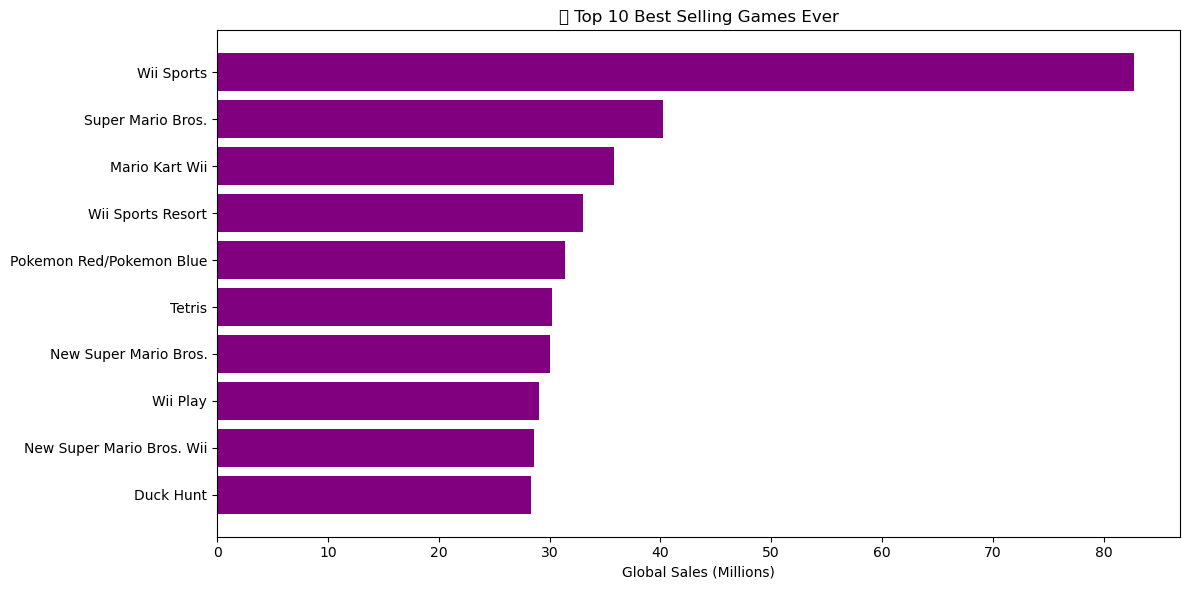

 Chart saved!


In [23]:
#Top 10 Chart:
# Bar chart — Top 10 games
plt.figure(figsize=(12, 6))
plt.barh(top_games["Name"], top_games["Global_Sales"], color="purple")
plt.xlabel("Global Sales (Millions)")
plt.title("🎮 Top 10 Best Selling Games Ever")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig("top10_games.png")
plt.show()
print(" Chart saved!")


In [25]:
#Best Genre:
# Sales by Genre
genre_sales = df.groupby("Genre")["Global_Sales"].sum().sort_values(ascending=False)

print(" SALES BY GENRE:")
print("━"*35)
for genre, sales in genre_sales.items():
    print(f"{genre:15} | {sales:.1f}M")

 SALES BY GENRE:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Action          | 1722.8M
Sports          | 1309.2M
Shooter         | 1026.2M
Role-Playing    | 923.8M
Platform        | 829.1M
Misc            | 789.9M
Racing          | 726.8M
Fighting        | 444.1M
Simulation      | 390.0M
Puzzle          | 242.2M
Adventure       | 234.6M
Strategy        | 173.3M


C:\Users\user\AppData\Local\Temp\ipykernel_1864\2452574186.py:9: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_1864\2452574186.py:10: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  plt.savefig("genre_sales.png")
C:\Users\user\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


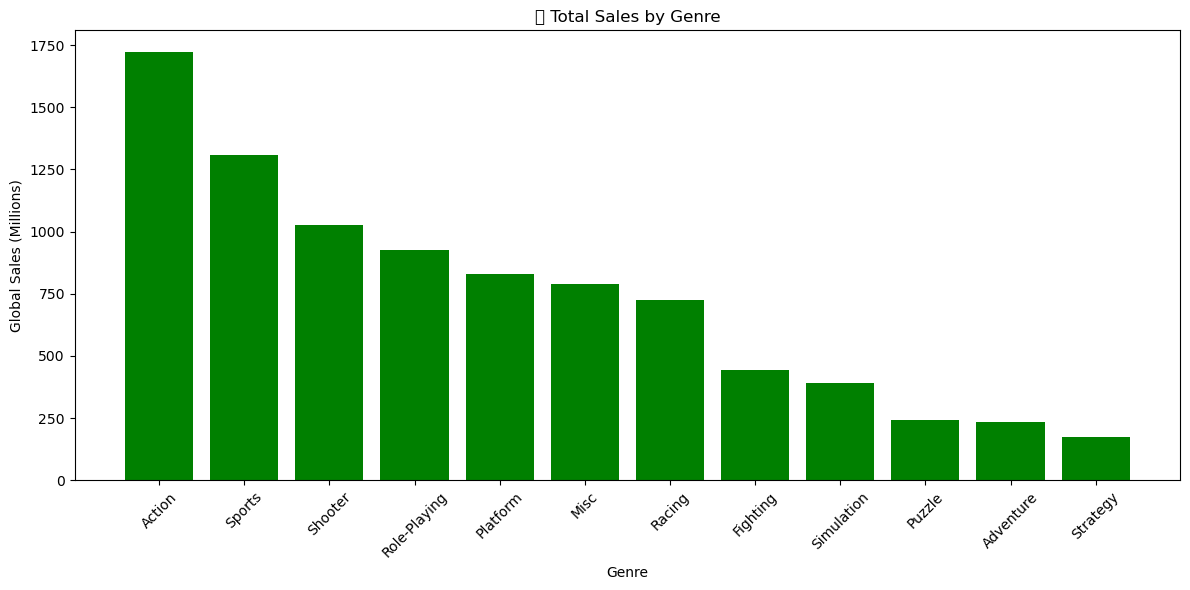

 Chart saved!


In [27]:
#Genre Chart:
# Bar chart — Genre sales
plt.figure(figsize=(12, 6))
plt.bar(genre_sales.index, genre_sales.values, color="green")
plt.xlabel("Genre")
plt.ylabel("Global Sales (Millions)")
plt.title("🎯 Total Sales by Genre")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("genre_sales.png")
plt.show()
print(" Chart saved!")

In [28]:
#Best Platform:
# Top 10 platforms by sales
platform_sales = df.groupby("Platform")["Global_Sales"].sum().sort_values(ascending=False).head(10)

print(" TOP 10 PLATFORMS BY SALES:")
print("━"*35)
for platform, sales in platform_sales.items():
    print(f"{platform:10} | {sales:.1f}M")

 TOP 10 PLATFORMS BY SALES:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
PS2        | 1233.5M
X360       | 969.6M
PS3        | 949.4M
WII        | 909.8M
DS         | 818.9M
PS         | 727.4M
GBA        | 305.6M
PSP        | 291.7M
PS4        | 278.1M
PC         | 254.7M


C:\Users\user\AppData\Local\Temp\ipykernel_1864\2377036112.py:8: UserWarning: Glyph 128377 (\N{JOYSTICK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_1864\2377036112.py:9: UserWarning: Glyph 128377 (\N{JOYSTICK}) missing from font(s) DejaVu Sans.
  plt.savefig("platform_sales.png")
C:\Users\user\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128377 (\N{JOYSTICK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


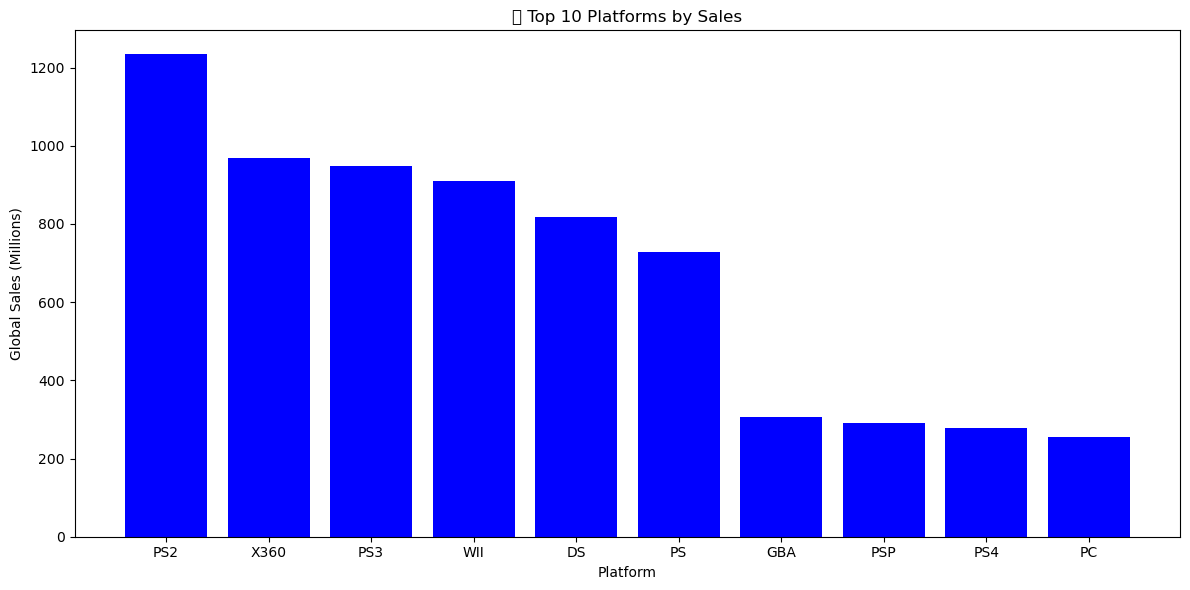

 Chart saved!


In [29]:
#Platform Chart:
# Bar chart — Platform sales
plt.figure(figsize=(12, 6))
plt.bar(platform_sales.index, platform_sales.values, color="blue")
plt.xlabel("Platform")
plt.ylabel("Global Sales (Millions)")
plt.title("🕹️ Top 10 Platforms by Sales")
plt.tight_layout()
plt.savefig("platform_sales.png")
plt.show()
print(" Chart saved!")

C:\Users\user\AppData\Local\Temp\ipykernel_1864\1462182559.py:13: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_1864\1462182559.py:14: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.savefig("sales_trend.png")
C:\Users\user\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


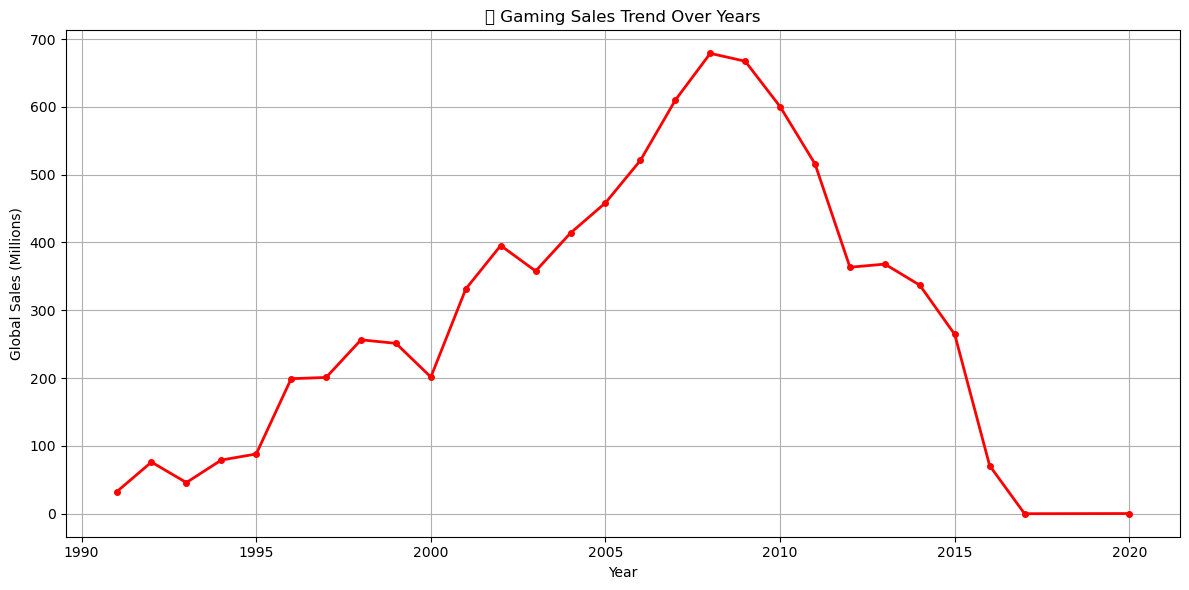

 Chart saved!


In [30]:
#Sales by Year:
# Sales trend over years
year_sales = df.groupby("Year")["Global_Sales"].sum()
year_sales = year_sales[year_sales.index > 1990]  # from 1990 only

plt.figure(figsize=(12, 6))
plt.plot(year_sales.index, year_sales.values,
         color="red", linewidth=2, marker="o", markersize=4)
plt.xlabel("Year")
plt.ylabel("Global Sales (Millions)")
plt.title("📈 Gaming Sales Trend Over Years")
plt.grid(True)
plt.tight_layout()
plt.savefig("sales_trend.png")
plt.show()
print(" Chart saved!")

In [31]:
#Top Publishers:
# Top 10 publishers
publisher_sales = df.groupby("Publisher")["Global_Sales"].sum().sort_values(ascending=False).head(10)

print(" TOP 10 GAME PUBLISHERS:")
print("━"*40)
for pub, sales in publisher_sales.items():
    print(f"{pub:25} | {sales:.1f}M")

 TOP 10 GAME PUBLISHERS:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Nintendo                  | 1784.4M
Electronic Arts           | 1093.4M
Activision                | 721.4M
Sony Computer Entertainment | 607.3M
Ubisoft                   | 473.5M
Take-Two Interactive      | 399.3M
THQ                       | 340.4M
Konami Digital Entertainment | 278.6M
Sega                      | 270.7M
Namco Bandai Games        | 253.7M


In [33]:
# Summary Report:
# Final summary
print("\n" + "━"*45)
print(" GAMING ANALYTICS REPORT")
print("━"*45)
print(f"  Total Games Analysed : {len(df)}")
print(f"  Best Selling Game    : {df.loc[df['Global_Sales'].idxmax(), 'Name']}")
print(f"  Most Popular Genre   : {genre_sales.idxmax()}")
print(f"  Most Popular Platform: {platform_sales.idxmax()}")
print(f"  Top Publisher        : {publisher_sales.idxmax()}")
print(f"  Peak Sales Year      : {year_sales.idxmax()}")
print(f"  Total Global Sales   : {df['Global_Sales'].sum():.1f}M")
print("━"*45)


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
 GAMING ANALYTICS REPORT
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Total Games Analysed : 16291
  Best Selling Game    : Wii Sports
  Most Popular Genre   : Action
  Most Popular Platform: PS2
  Top Publisher        : Nintendo
  Peak Sales Year      : 2008
  Total Global Sales   : 8812.0M
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
